## import libraries and load data

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
df = pd.read_excel("final_data_set.xlsx",sheet_name="Fact_SurveyResponses")

## Explore the Data

In [67]:
df.head()

,age,gender,status,daily screen time hours,daily social media hours,physical exercise,sleep hour,check phone morning,irritable recently,top apps,doomscroll level,ContentFormat_ID,StayFactor_ID,SkipPoint_KEY,VisualEffect_Key
0,18-24,Male,S,More than 8 hours,1 – 3 hours,I was playing and I stopped,5 – 6 hours,Always,No,Instagram,1,VID_SHORT,TONE_STYLE,SKIP_PACE,YES_SIG
1,18-24,Male,S,More than 8 hours,5 – 7 hours,I was playing and I stopped,6 – 7 hours,Always,Yes,WhatsApp,2,STORY_REAL,TONE_STYLE,SKIP_INTEREST,YES_SIG
2,18-24,Female,S,More than 8 hours,3 – 5 hours,I was playing and I stopped,More than 8 hours,Always,Yes,Instagram,2,STORY_REAL,TONE_STYLE,SKIP_PACE,NO_CONTENT
3,18-24,Female,S,More than 8 hours,3 – 5 hours,Yes,More than 8 hours,Always,No,Tiktok,2,VID_SHORT,VISUAL_MQ,SKIP_INTEREST,YES_SIG
4,18-24,Male,S,6 - 8 hours,3 – 5 hours,No,More than 8 hours,Always,No,Facebook,3,VID_SHORT,VISUAL_MQ,SKIP_PACE,NO_CONTENT


In [68]:
df.shape

(217, 15)

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   age                       217 non-null    object
 1   gender                    217 non-null    object
 2   status                    217 non-null    object
 3   daily screen time hours   217 non-null    object
 4   daily social media hours  217 non-null    object
 5   physical exercise         217 non-null    object
 6   sleep hour                217 non-null    object
 7   check phone morning       217 non-null    object
 8   irritable recently        217 non-null    object
 9   top apps                  217 non-null    object
 10  doomscroll level          217 non-null    int64 
 11  ContentFormat_ID          217 non-null    object
 12  StayFactor_ID             217 non-null    object
 13  SkipPoint_KEY             217 non-null    object
 14  VisualEffect_Key          

In [70]:
df.isnull().sum()

age                         0
gender                      0
status                      0
daily screen time hours     0
daily social media hours    0
physical exercise           0
sleep hour                  0
check phone morning         0
irritable recently          0
top apps                    0
doomscroll level            0
ContentFormat_ID            0
StayFactor_ID               0
SkipPoint_KEY               0
VisualEffect_Key            0
dtype: int64

In [71]:
df.duplicated().sum()

np.int64(3)

In [72]:
df.columns

Index(['age', 'gender', 'status', 'daily screen time hours',
       'daily social media hours', 'physical exercise', 'sleep hour',
       'check phone morning', 'irritable recently', 'top apps',
       'doomscroll level', 'ContentFormat_ID', 'StayFactor_ID',
       'SkipPoint_KEY', 'VisualEffect_Key'],
      dtype='object')

In [73]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
doomscroll level,217.0,1.732719,0.640087,1.0,1.0,2.0,2.0,3.0


In [74]:
df.describe(include='object').T

,count,unique,top,freq
age,217,6,18-24,170
gender,217,2,Male,128
status,217,4,S,152
daily screen time hours,217,5,6 - 8 hours,65
daily social media hours,217,5,1 – 3 hours,76
physical exercise,217,3,I was playing and I stopped,97
sleep hour,217,5,5 – 6 hours,64
check phone morning,217,3,Always,129
irritable recently,217,3,No,96
top apps,217,9,Facebook,66


After an initial check, we identified several areas that require adjustment:

1. **Column Data Types**: Certain columns, such as `"age"` and `"gender"`, are currently stored as `object`. It is recommended to convert them to `category` for better data handling and analysis.

2. **Duplicate Records**: The dataset contains duplicate entries, which will be removed to ensure data integrity.

## Handle the problems

In [75]:
# remove duplicates
df=df.drop_duplicates(keep='first')

In [76]:
df.duplicated().sum()

np.int64(0)

In [77]:
# change data types for columns
category_cols = ['age', 'gender', 'status', 'daily screen time hours', 'daily social media hours',
            'physical exercise', 'sleep hour', 'check phone morning', 'irritable recently']
for col in category_cols:
    df[col] = df[col].astype('category')

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 214 entries, 0 to 216
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   age                       214 non-null    category
 1   gender                    214 non-null    category
 2   status                    214 non-null    category
 3   daily screen time hours   214 non-null    category
 4   daily social media hours  214 non-null    category
 5   physical exercise         214 non-null    category
 6   sleep hour                214 non-null    category
 7   check phone morning       214 non-null    category
 8   irritable recently        214 non-null    category
 9   top apps                  214 non-null    object  
 10  doomscroll level          214 non-null    int64   
 11  ContentFormat_ID          214 non-null    object  
 12  StayFactor_ID             214 non-null    object  
 13  SkipPoint_KEY             214 non-null    object  
 14 

# Data Cleaning and Preprocessing Summary

After reviewing the dataset, the following adjustments have been applied:

1. **Column Data Type Conversion**  
   - Converted several columns from `object` to `category` for better analysis and memory efficiency.  
   - Columns updated:  
     - `"age"`  
     - `"gender"`  
     - `"status"`  
     - `"daily screen time hours"`  
     - `"daily social media hours"`  
     - `"physical exercise"`  
     - `"sleep hour"`  
     - `"check phone morning"`  
     - `"irritable recently"`  

3. **Duplicate Removal**  
   - Identified and removed duplicate rows to maintain data integrity.



## EDA

In [83]:
df['doomscroll level'].value_counts()

doomscroll level
2    111
1     81
3     22
Name: count, dtype: int64

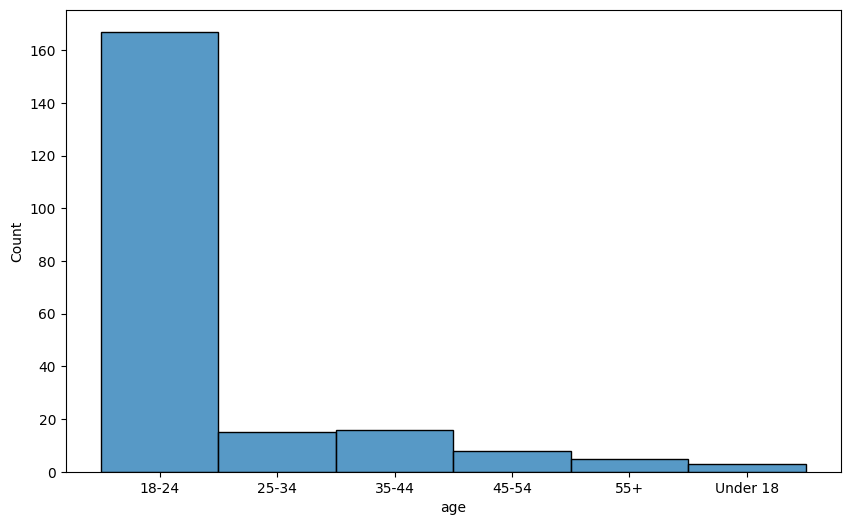

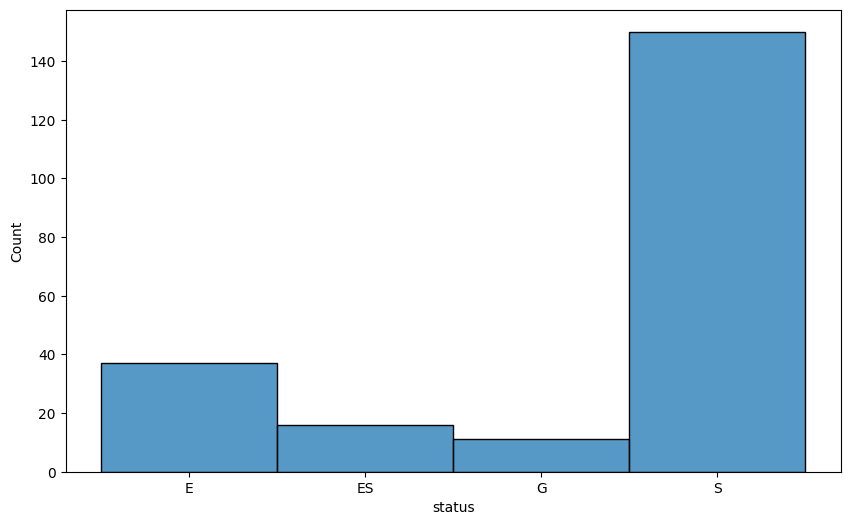

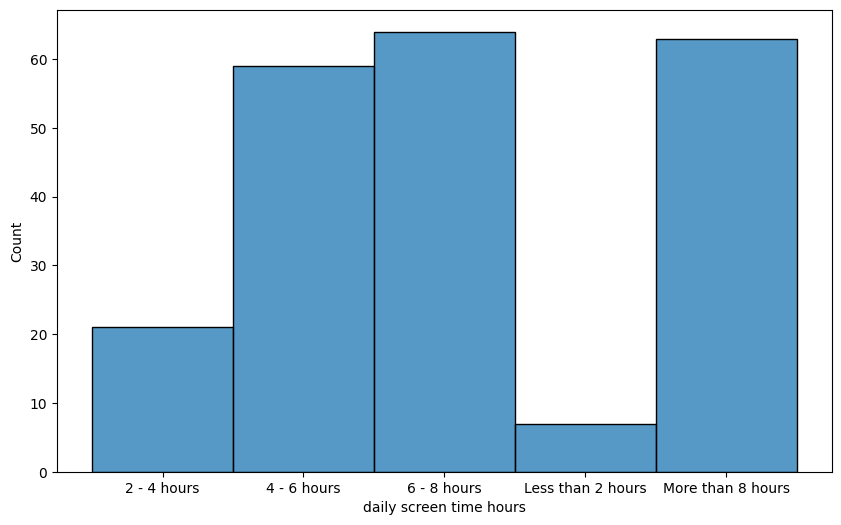

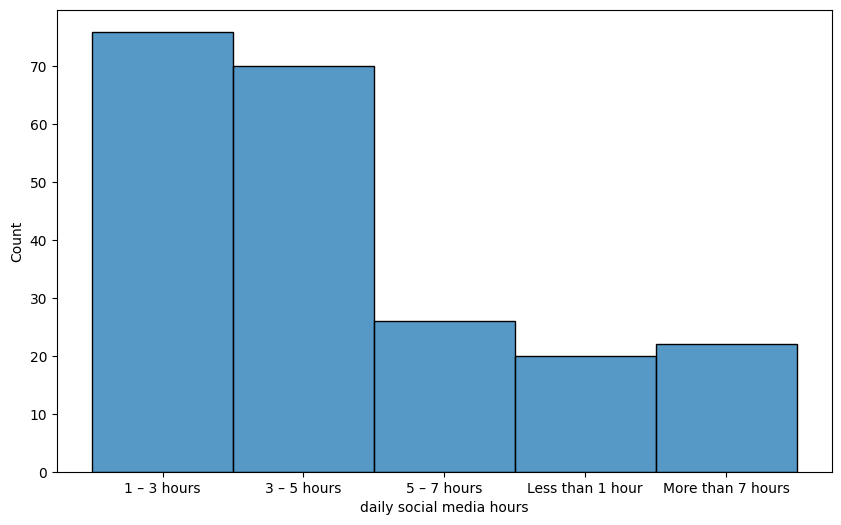

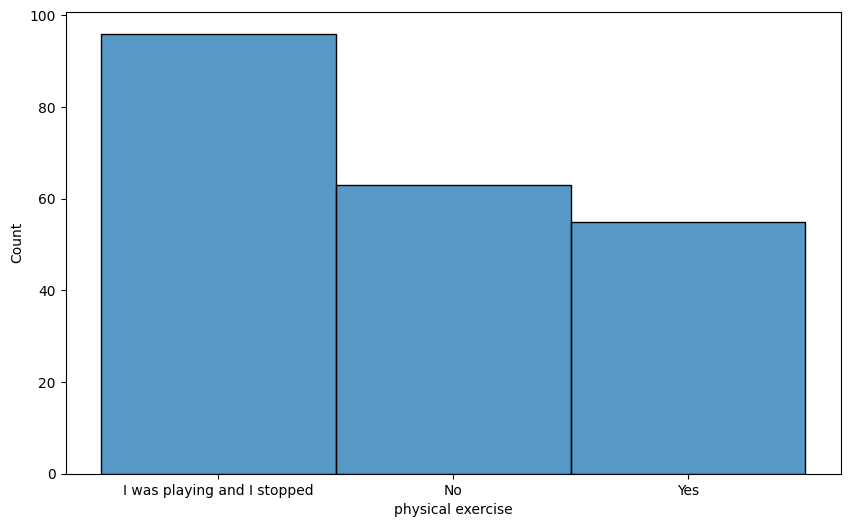

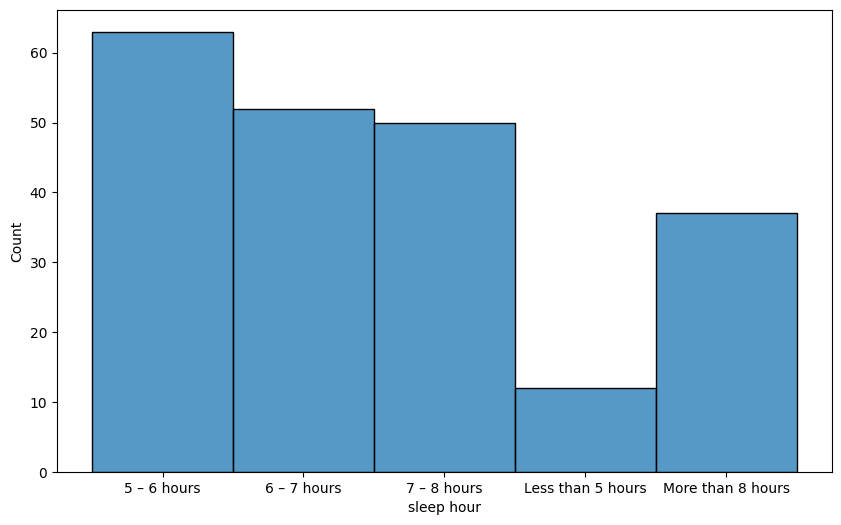

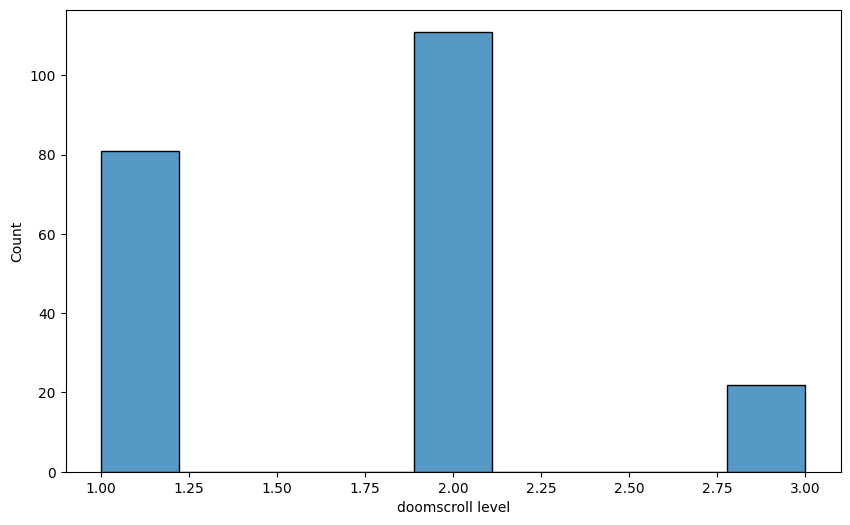

In [91]:
# histogram to distribution
columns_for_histogram = [
    "age",
    "status",
    "daily screen time hours",
    "daily social media hours",
    "physical exercise",
    "sleep hour",
    "doomscroll level"
]
for i in columns_for_histogram:
    plt.figure(figsize=(10,6)) 
    sns.histplot(data=df,x=i)
    plt.show()

# Data Insights from the histograms

Based on the visualizations, we can observe the following patterns:

1. **Demographics**: The majority of participants belong to Generation Z and are currently students.  

2. **Screen Usage**: Most participants exhibit high daily screen time, while their social media usage remains moderate. This suggests that a significant portion of their screen time may be dedicated to work or study activities.  

3. **Physical Activity**: Many participants are currently inactive in terms of sports, although they were active in the past.  

4. **Doomscrolling Behavior**: Most participants display a moderate level of doomscrolling.

In [86]:
df.columns.tolist()

['age',
 'gender',
 'status',
 'daily screen time hours',
 'daily social media hours',
 'physical exercise',
 'sleep hour',
 'check phone morning',
 'irritable recently',
 'top apps',
 'doomscroll level',
 'ContentFormat_ID',
 'StayFactor_ID',
 'SkipPoint_KEY',
 'VisualEffect_Key']

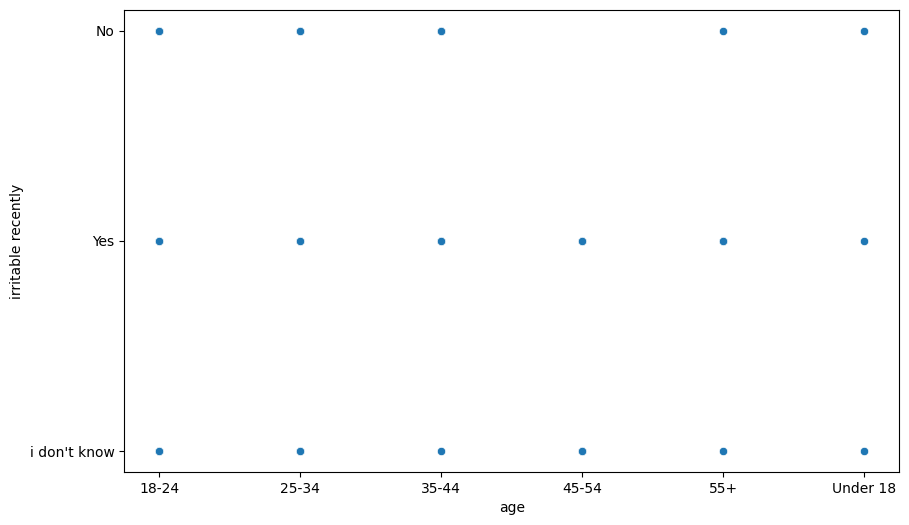

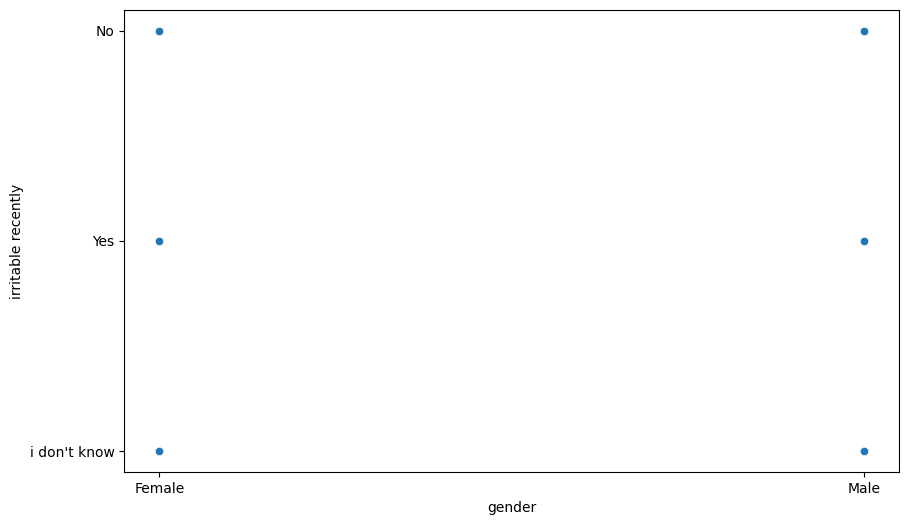

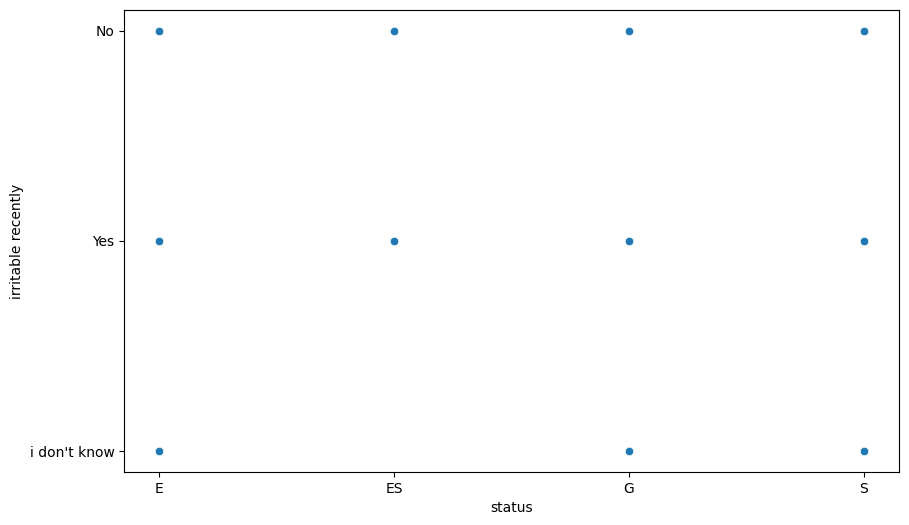

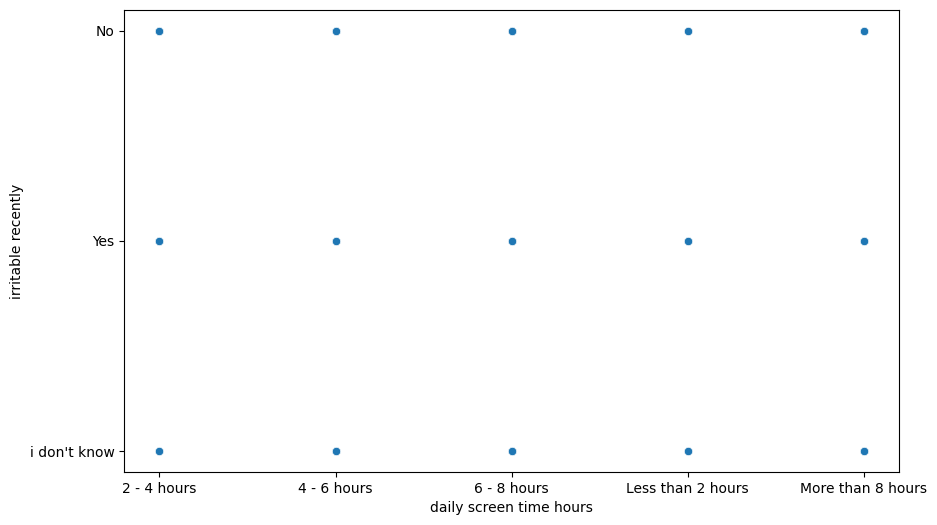

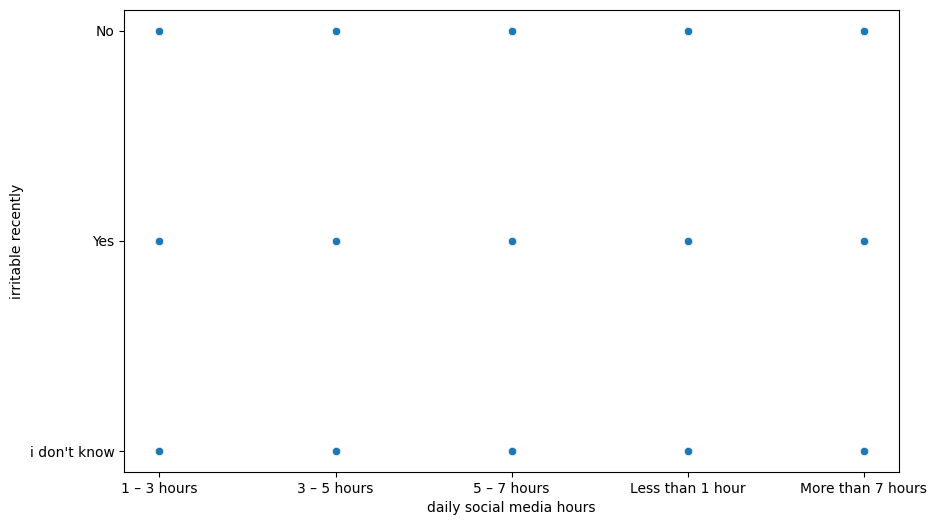

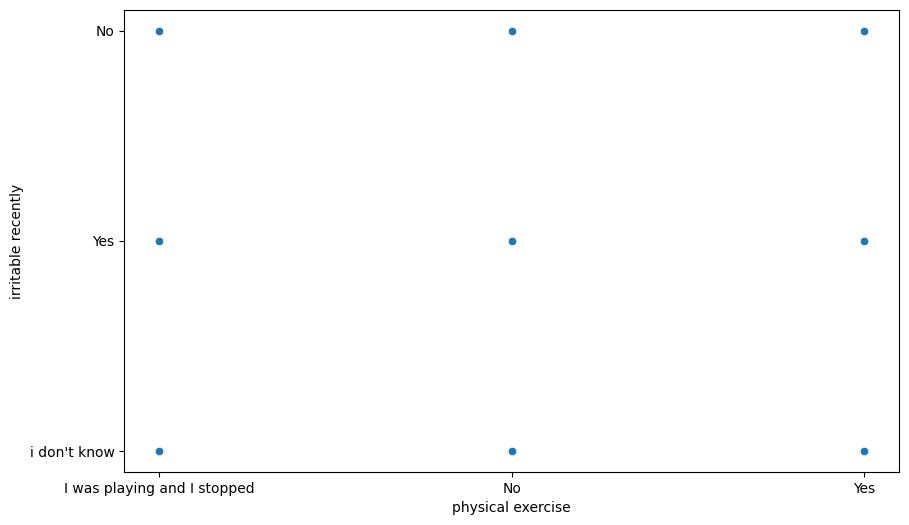

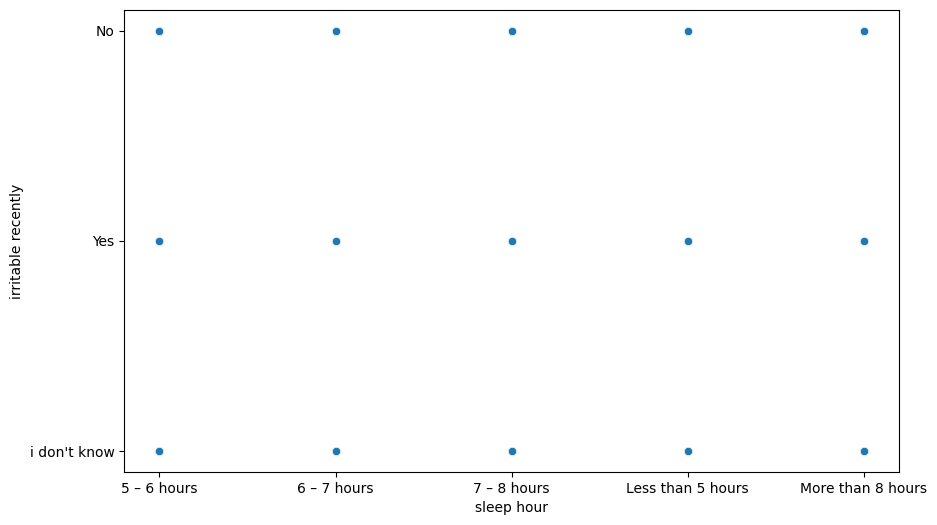

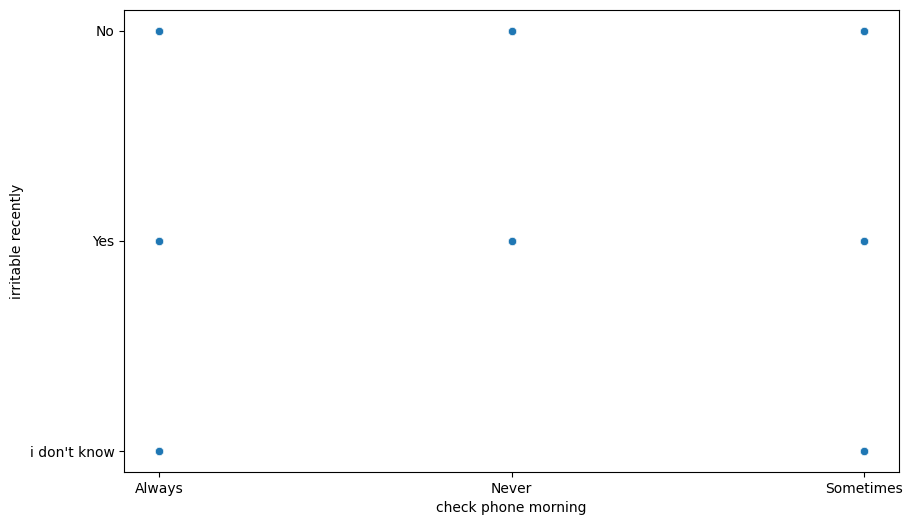

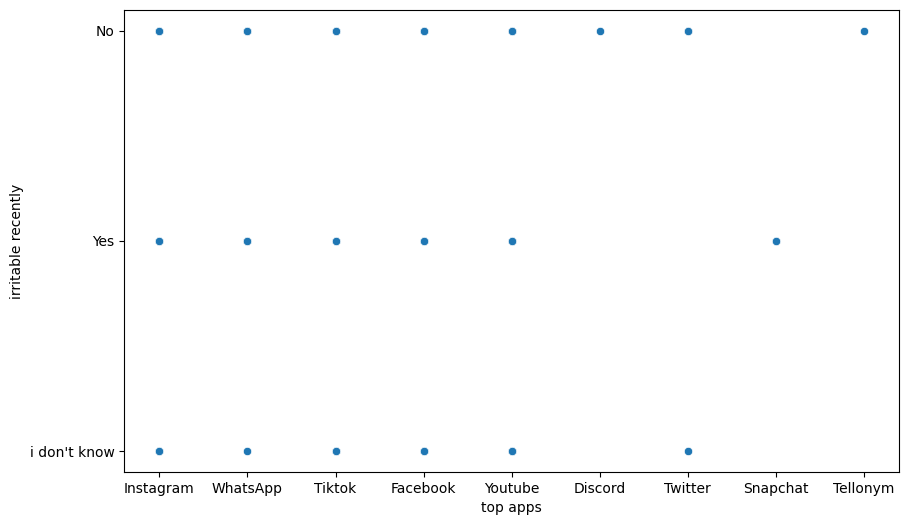

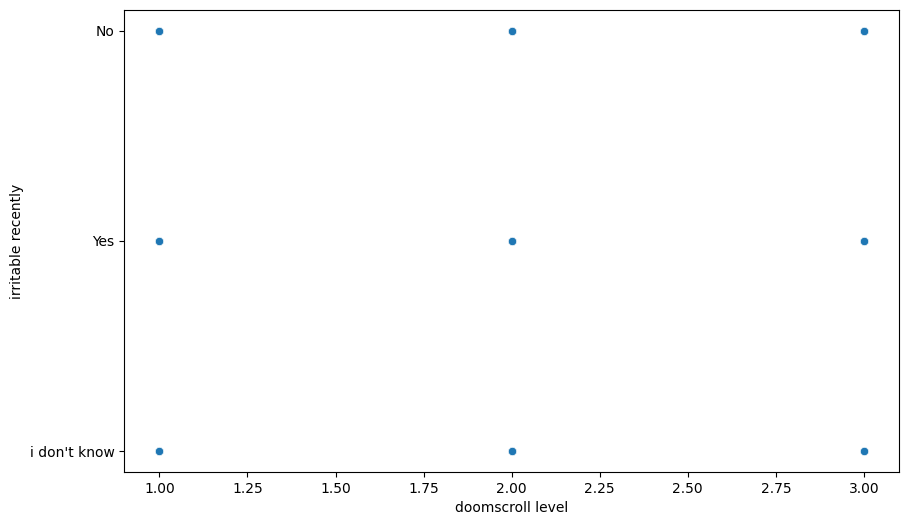

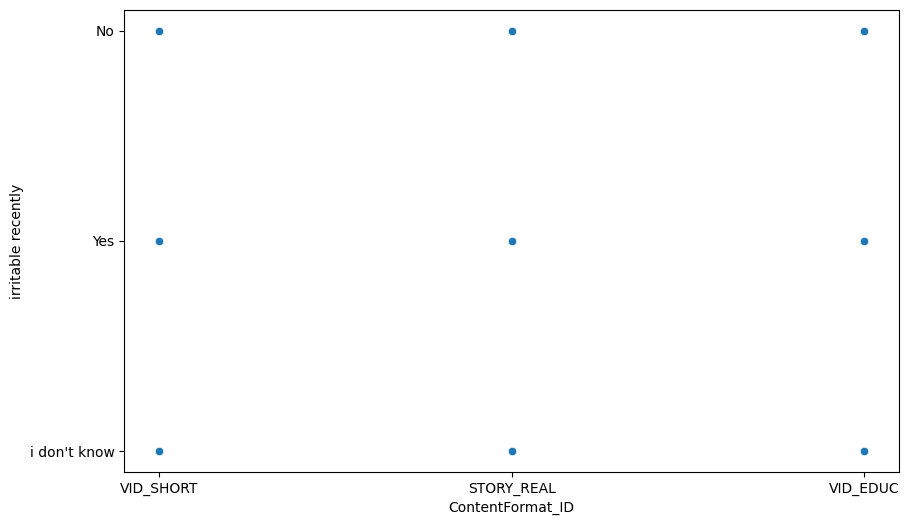

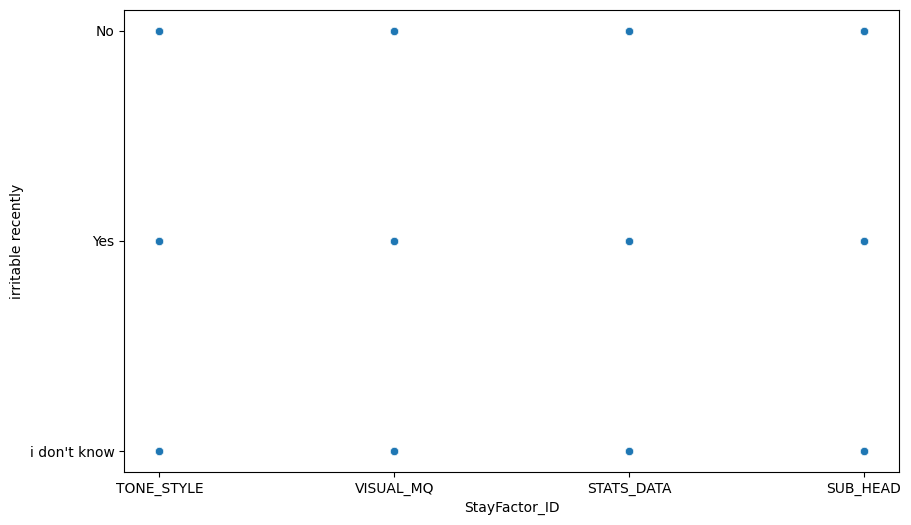

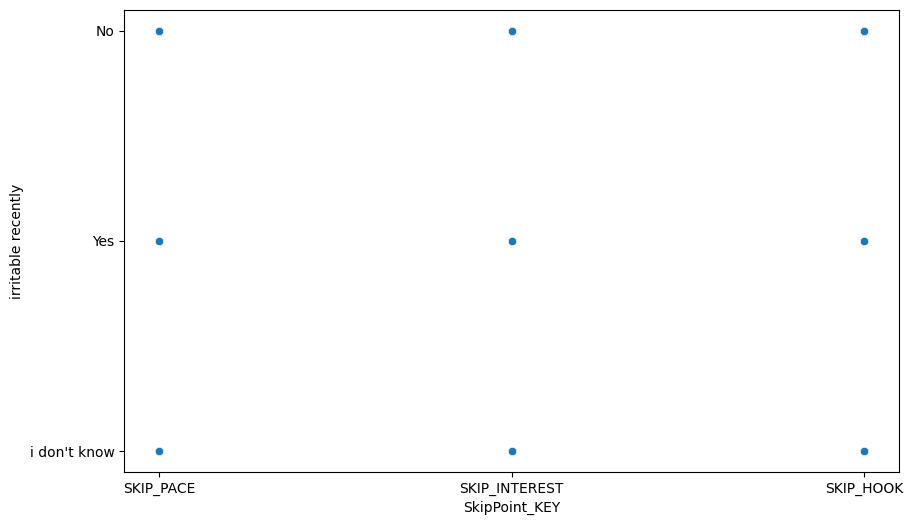

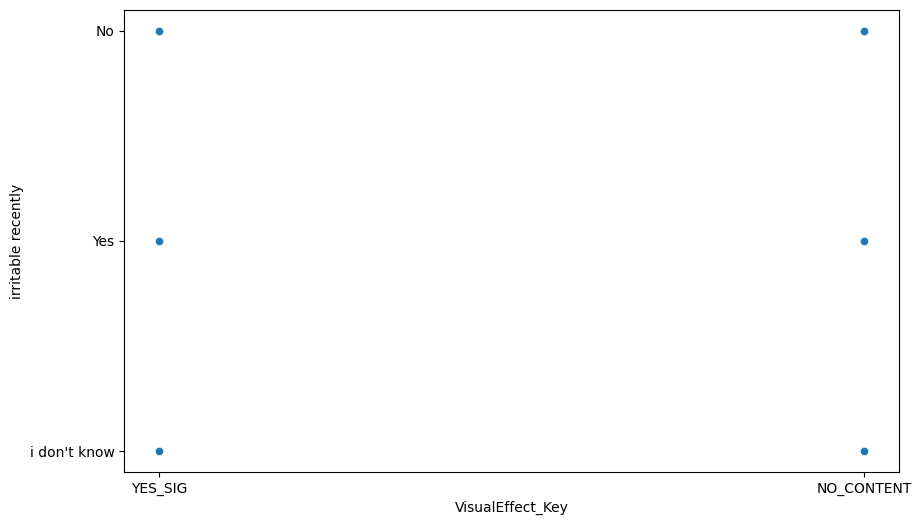

In [95]:
#scatterplots to check relationships
for i in ['age','gender',
            'status',
            'daily screen time hours',
            'daily social media hours',
            'physical exercise',
            'sleep hour',
            'check phone morning',
            'top apps',
            'doomscroll level',
            'ContentFormat_ID',
            'StayFactor_ID',
            'SkipPoint_KEY',
            'VisualEffect_Key']:
    plt.figure(figsize=(10,6)) 
    sns.scatterplot(data=df,x=i,y=df['irritable recently'])
    plt.show()

# Scatterplot Analysis

Based on the scatterplots, no obvious relationships were observed between any of the numerical columns and the **`irritable recently`** variable.

df['social_media_ratio'] = df['daily social media hours_numeric'] / df['total_screen_time']
df['active_before'] = df['physical exercise'].apply(lambda x: 0 if x == "I am not active" else 1)

## Feature Engineering

In [112]:
# categorize the values of screen time
screen_time_map = {
    'Less than 2 hours': 'Very Low',
    '2 - 4 hours': 'Low',
    '4 - 6 hours': 'Medium',
    '6 - 8 hours': 'High',
    'More than 8 hours': 'Very High'
}
df['screen_time_level'] = df['daily screen time hours'].map(screen_time_map)

In [109]:
# categorize the values of social media hours
social_hours_map = {
    'Less than 1 hour':"very Low",
    '1 – 3 hours': 'Low',
    '3 – 5 hours': 'Medium',
    '5 – 7 hours': 'High',
    'More than 7 hours': 'Very High'
}
df['social_media_level'] = df['daily social media hours'].map(social_hours_map)

In [115]:
sleep_hours_map = {
    'Less than 5 hours':"very Low",
    '5 – 6 hours': 'Low',
    '6 – 7 hours': 'Good',
    '7 – 8 hours': 'High',
    'More than 8 hours': 'Very High'
}
df['sleep_level'] = df['sleep hour'].map(sleep_hours_map)

# Added Features and Categorical Levels

During the feature engineering process, several new columns were added to the dataset to facilitate analysis and modeling. These columns capture **categorical levels** for various behaviors and summarize participant activity.

---

##  Screen Usage

| Original Column | New Column | Description |
|-----------------|------------|-------------|
| daily screen time hours | screen_time_level | Categorizes participants' daily screen time into levels such as Very Low, Low, Medium, High, Very High |
| daily social media hours | social_media_level | Categorizes participants' daily social media usage into levels such as Low, Medium, High |



##  Sleep & Physical Activity

| Original Column | New Column | Description |
|-----------------|------------|-------------|
| sleep hour | sleep_level | Categorizes participants' sleep duration into levels such as Very Low, Low, Medium, High, Very High |



In [121]:
# save the data
df.to_csv("survey_data_edited.csv", index=False)